In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('SalesDataset.csv')

In [3]:
monthly_sales = df.groupby('Year-Month')['Amount'].sum().reset_index()

In [4]:
monthly_sales.set_index('Year-Month', inplace=True)

<Figure size 1200x600 with 0 Axes>

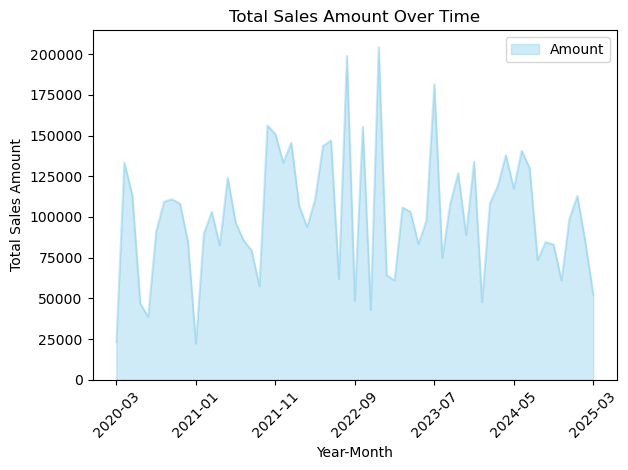

In [5]:
plt.figure(figsize=(12, 6))
monthly_sales.plot.area(alpha=0.4, color="skyblue")
plt.title('Total Sales Amount Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Total Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
category_sales = df.pivot_table(values='Amount', index='Year-Month', columns='Category', aggfunc='sum')

<Figure size 1200x600 with 0 Axes>

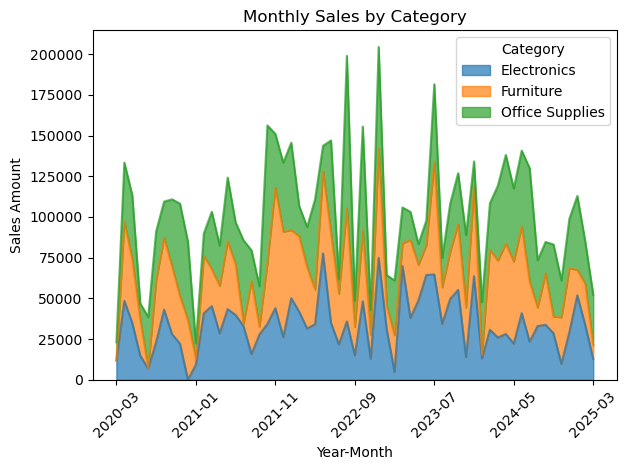

In [7]:
plt.figure(figsize=(12, 6))
category_sales.plot.area(alpha=0.7)  # Alpha to adjust transparency
plt.title('Monthly Sales by Category')
plt.xlabel('Year-Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

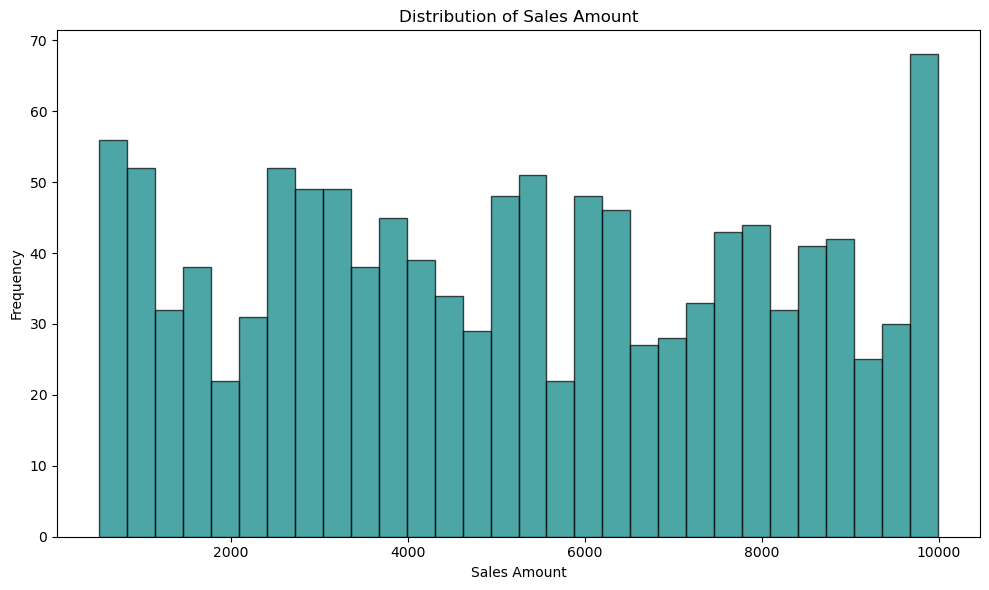

In [8]:
#Histogram

plt.figure(figsize=(10, 6))
plt.hist(df['Amount'], bins=30, color='teal', alpha=0.7, edgecolor='black')
plt.title('Distribution of Sales Amount')
plt.xlabel('Sales Amount')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

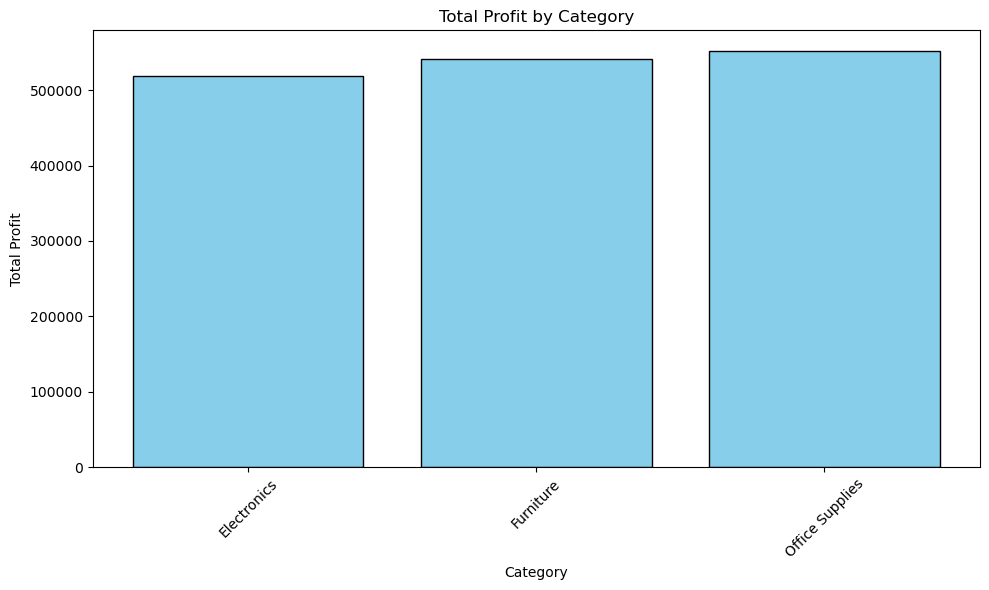

In [9]:
category_profit = df.groupby('Category')['Profit'].sum().reset_index()

# Create a vertical bar chart using Matplotlib
plt.figure(figsize=(10, 6))
plt.bar(category_profit['Category'], category_profit['Profit'], color='skyblue', edgecolor='black')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.xticks(rotation=45)  # Rotate labels if necessary for readability
plt.tight_layout()       # Adjust layout for clean presentation
plt.show()

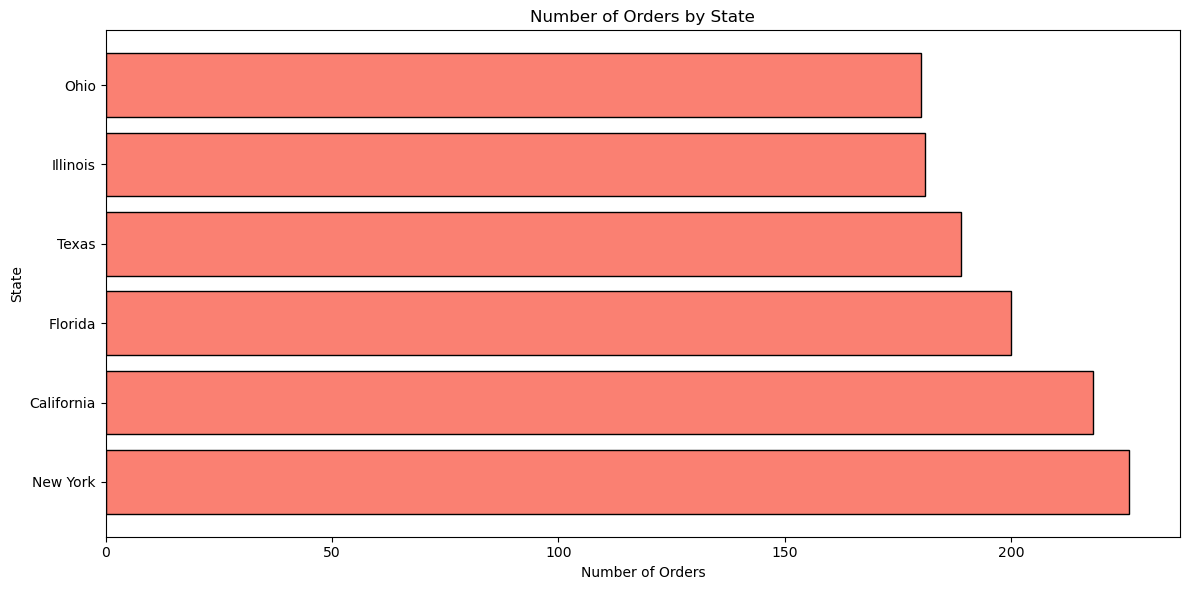

In [10]:
state_counts = df['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Count']

# Create a horizontal bar chart
plt.figure(figsize=(12, 6))
plt.barh(state_counts['State'], state_counts['Count'], color='salmon', edgecolor='black')
plt.title('Number of Orders by State')
plt.xlabel('Number of Orders')
plt.ylabel('State')
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 0 Axes>

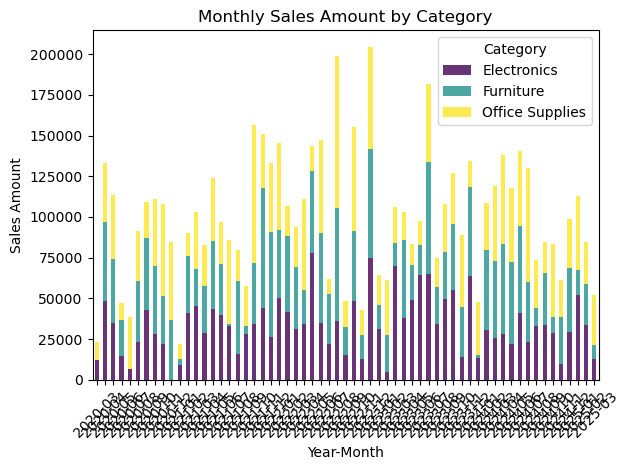

In [11]:
monthly_category_sales = df.pivot_table(values='Amount', index='Year-Month', columns='Category', aggfunc='sum')

# Plot the stacked bar chart
plt.figure(figsize=(12, 6))
monthly_category_sales.plot(kind='bar', stacked=True, colormap='viridis', alpha=0.8)
plt.title('Monthly Sales Amount by Category')
plt.xlabel('Year-Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

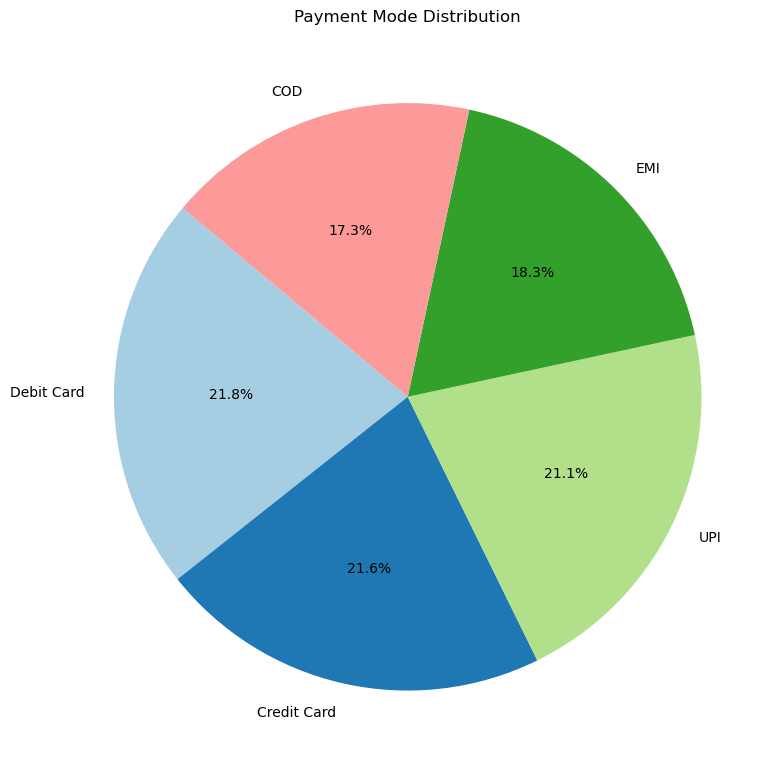

In [12]:
payment_counts = df['PaymentMode'].value_counts()

# Create a pie chart for PaymentMode distribution
plt.figure(figsize=(8, 8))
plt.pie(payment_counts, labels=payment_counts.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Paired.colors)
plt.title('Payment Mode Distribution')
plt.tight_layout()
plt.show()

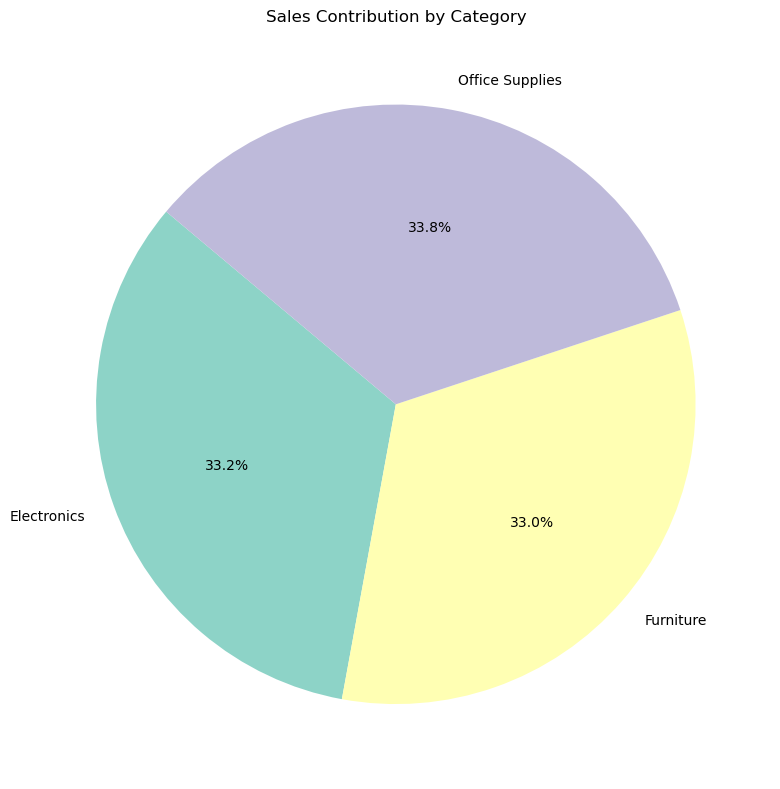

In [13]:
category_sales = df.groupby('Category')['Amount'].sum()

# Create a pie chart for sales by Category
plt.figure(figsize=(8, 8))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', startangle=140, colors=plt.cm.Set3.colors)
plt.title('Sales Contribution by Category')
plt.tight_layout()
plt.show()

/var/folders/x2/sv4n6ff97g360s95c_r6941m0000gn/T/ipykernel_80399/2505768177.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Sub-Category', y='Profit', palette='coolwarm')


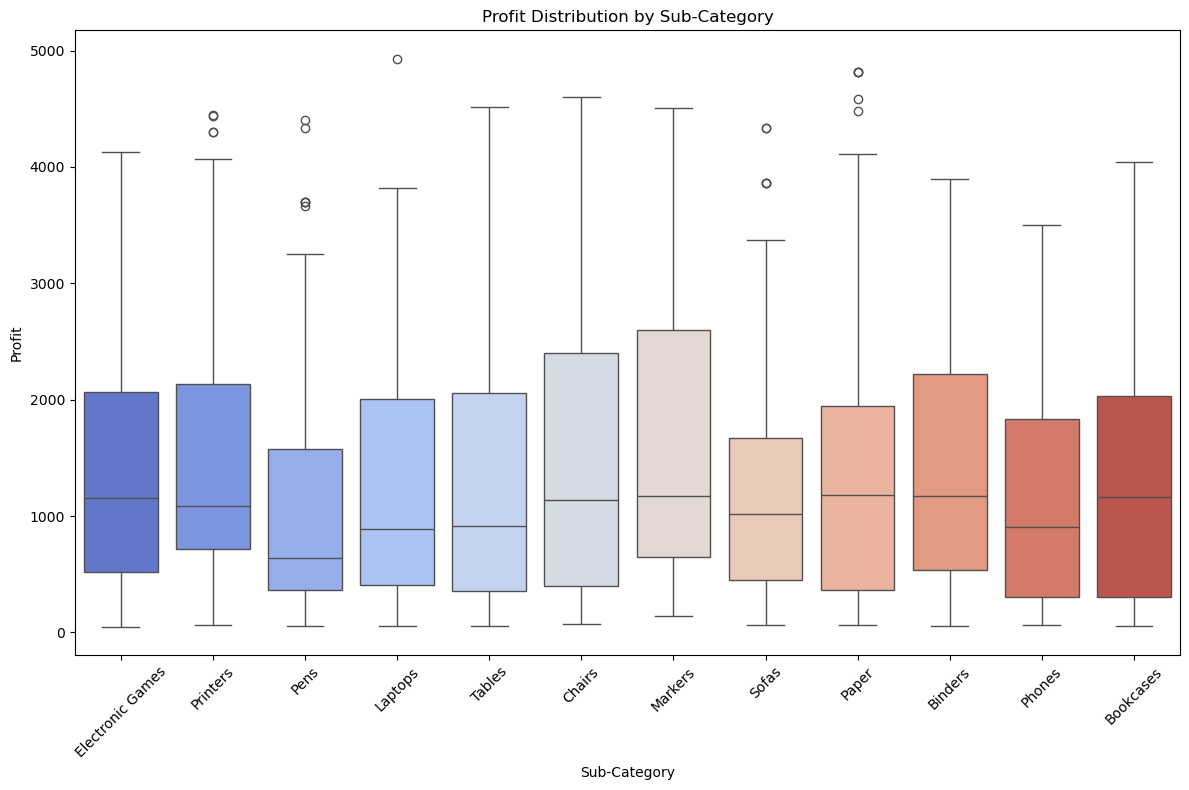

In [15]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.boxplot(data=df, x='Sub-Category', y='Profit', palette='coolwarm')
plt.title('Profit Distribution by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Profit')
plt.xticks(rotation=45)  # Rotate labels for better visibility
plt.tight_layout()
plt.show()

/var/folders/x2/sv4n6ff97g360s95c_r6941m0000gn/T/ipykernel_80399/4073638612.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='PaymentMode', y='Amount', palette='Set2')


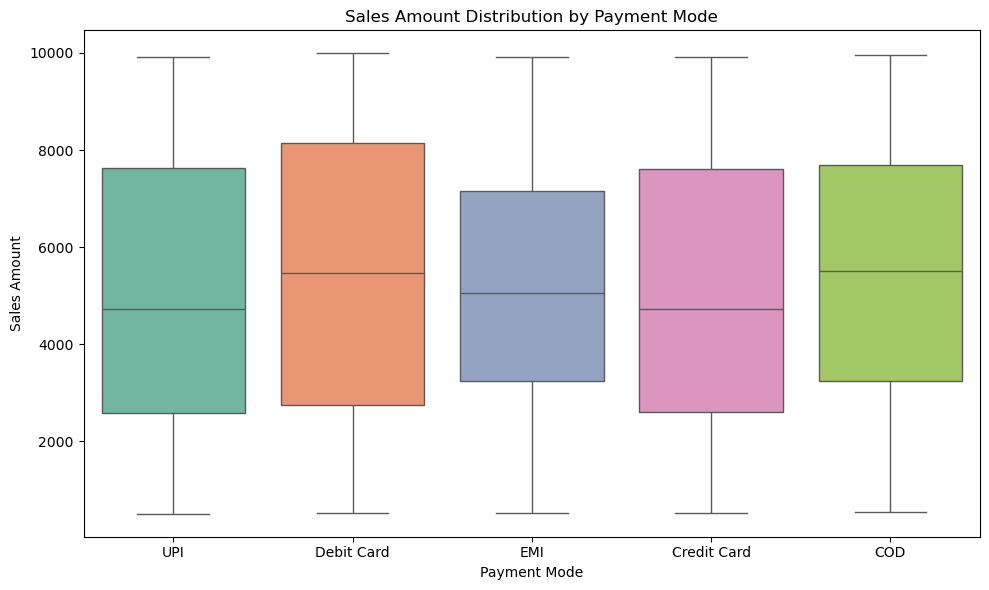

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='PaymentMode', y='Amount', palette='Set2')
plt.title('Sales Amount Distribution by Payment Mode')
plt.xlabel('Payment Mode')
plt.ylabel('Sales Amount')
plt.tight_layout()
plt.show()

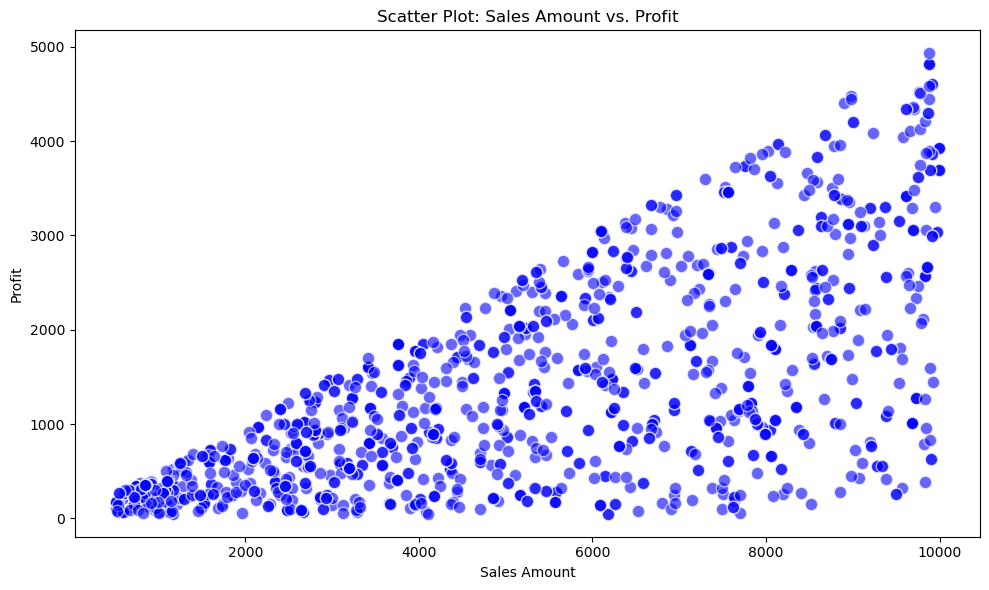

In [18]:
# Create a simple scatter plot using Matplotlib
plt.figure(figsize=(10, 6))
plt.scatter(df['Amount'], df['Profit'], color='blue', alpha=0.6, edgecolor='w', s=80)
plt.title('Scatter Plot: Sales Amount vs. Profit')
plt.xlabel('Sales Amount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

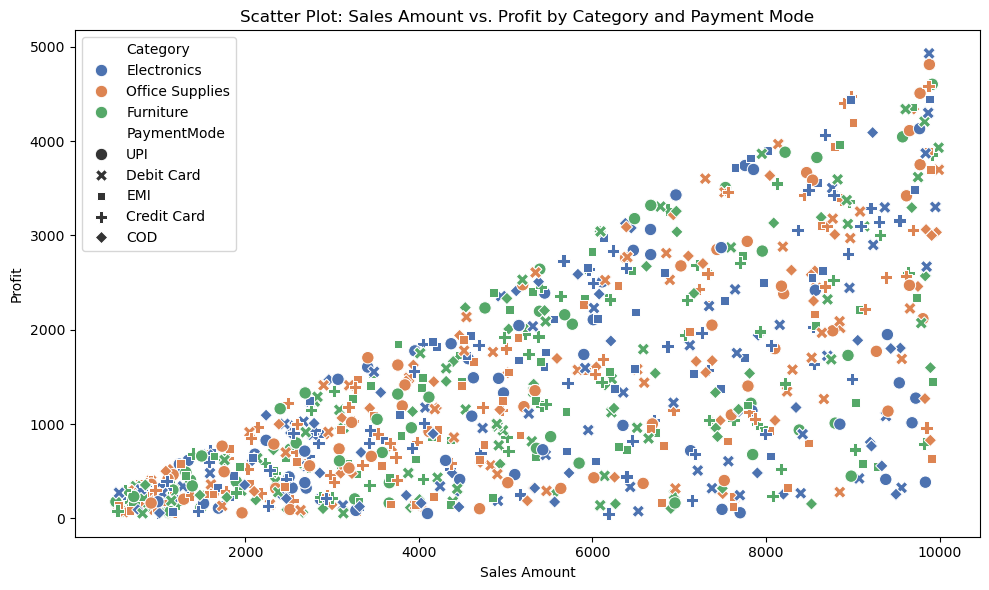

In [19]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Amount', y='Profit', hue='Category', style='PaymentMode', palette='deep', s=80)
plt.title('Scatter Plot: Sales Amount vs. Profit by Category and Payment Mode')
plt.xlabel('Sales Amount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

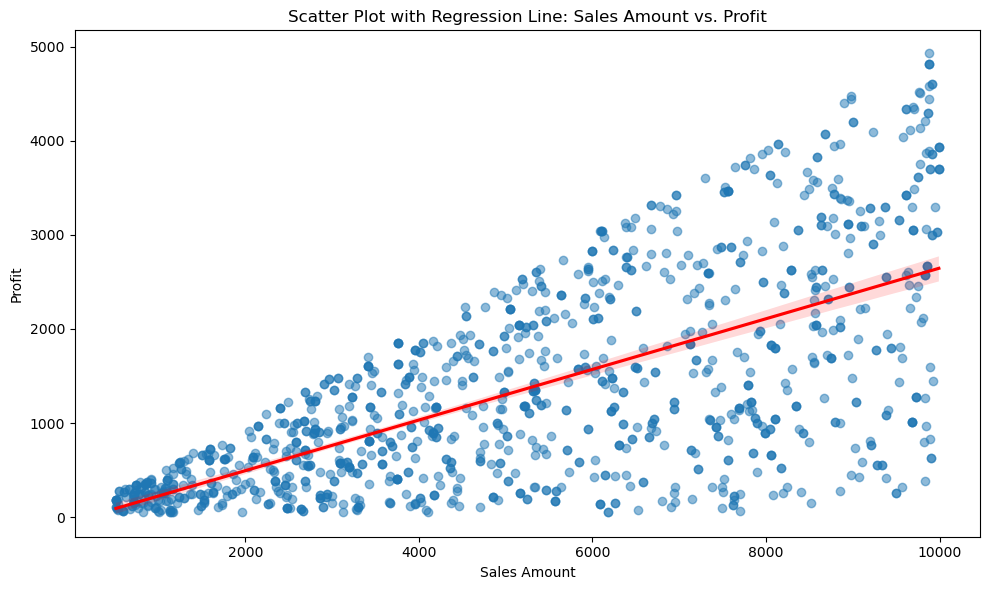

In [20]:
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Amount', y='Profit', scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Scatter Plot with Regression Line: Sales Amount vs. Profit')
plt.xlabel('Sales Amount')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

In [24]:
pip install squarify

Note: you may need to restart the kernel to use updated packages.


In [25]:
import squarify

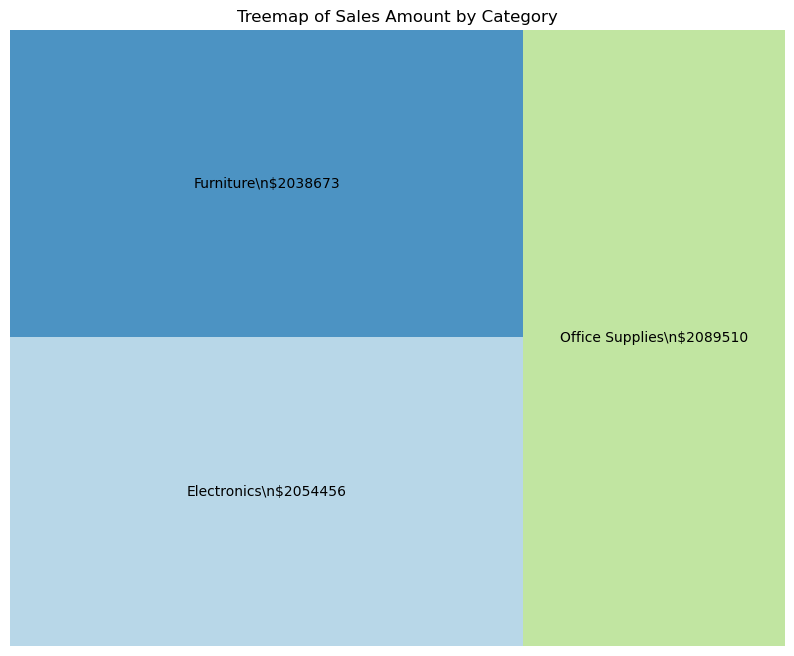

In [26]:
category_sales = df.groupby('Category')['Amount'].sum().reset_index()

# Prepare values for the treemap, using sales amounts
sizes = category_sales['Amount']
labels = category_sales.apply(lambda row: f"{row['Category']}\\n${row['Amount']:.0f}", axis=1)

# Create the treemap
plt.figure(figsize=(10, 8))
squarify.plot(sizes=sizes, label=labels, alpha=0.8, color=plt.cm.Paired.colors)
plt.axis('off')  # Turn off the axis to focus on the treemap only
plt.title('Treemap of Sales Amount by Category')
plt.show()

<Figure size 1200x600 with 0 Axes>

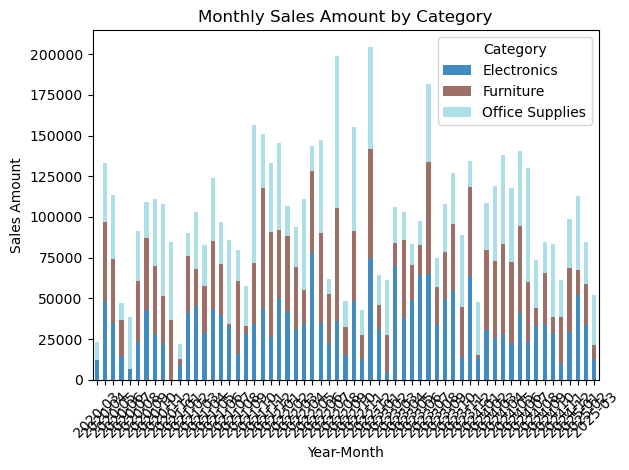

In [27]:
pivot_table = df.pivot_table(values='Amount', index='Year-Month', columns='Category', aggfunc='sum').fillna(0)

# Plot a stacked bar chart from the pivot table
plt.figure(figsize=(12, 6))
pivot_table.plot(kind='bar', stacked=True, colormap='tab20', alpha=0.85)
plt.title('Monthly Sales Amount by Category')
plt.xlabel('Year-Month')
plt.ylabel('Sales Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()